<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_08_application_of_machine_learning/Day_08_Application_of_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 From Fraud Detection to Customer Insights: Real-World Machine Learning Unleashed

---

## 🎬 The Story Begins: Machine Learning in Action

Every time you open Netflix, its recommendation engine suggests your next binge-watch. Every time your bank blocks a suspicious transaction, Machine Learning is working tirelessly behind the scenes. From predicting stock prices to diagnosing diseases, ML is no longer a futuristic concept—it's the invisible hand shaping our present.

### 🎯 Notebook Goal

This notebook is your passport to understanding the tangible impact of Machine Learning in the real world. We'll embark on a journey that:

*   **Connects ML concepts** to everyday problems.
*   **Showcases diverse models** solving distinct challenges.
*   **Illuminates *when* and *which* model** to deploy.
*   **Cultivates practical, industry-level intuition** for ML applications.


### 🌍 Your Real-World ML Adventure Awaits!

Get ready for a **practical playground** where we'll dive into hands-on examples across various industries, making this feel like a **top notebook** experience. Let's get started!

---

# 🌍 ML Is Everywhere: A Glimpse into its Global Footprint

Machine Learning is not confined to tech giants; it's a transformative force weaving its way into every fabric of our society. Let's explore its reach:

*   **🏥 Healthcare**: From early disease detection (e.g., cancer, diabetes) to personalized treatment plans and drug discovery, ML is revolutionizing patient care.
*   **💰 Finance**: Fraud detection, algorithmic trading, credit scoring, and risk assessment are just a few areas where ML algorithms protect assets and predict market trends.
*   **🛍️ E-commerce**: Recommendation systems (think Amazon, Shopify), personalized advertising, inventory management, and demand forecasting drive sales and enhance customer experience.
*   **📱 Social Media**: Content moderation, sentiment analysis, friend suggestions, and targeted advertising make our digital interactions more relevant (and sometimes, more addictive!).
*   **🚗 Autonomous Vehicles**: Self-driving cars rely heavily on ML for perception (object detection), prediction (forecasting other agents' movements), and planning (navigating complex environments).

And this is just the tip of the iceberg! Every day, new applications emerge, pushing the boundaries of what's possible.

---

# 🧠 Application #1: Classification - Safeguarding Transactions with Fraud Detection

Imagine a world where every financial transaction is automatically scrutinized for anomalies. This is the power of **Classification** in action. In ML, classification is about categorizing data into one of several predefined classes. For fraud detection, the classes are typically 'fraudulent' or 'legitimate'.

We'll build a model to identify potentially fraudulent transactions, acting as the silent guardian of your finances.

### 💻 Practical: Building a Fraud Detector

In [7]:
# Essential Libraries for Data Manipulation and Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for ML models, metrics, and data generation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification # For generating synthetic fraud data

# For visualization styling
sns.set_style('whitegrid')
plt.style.use('ggplot')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
# Generate a synthetic dataset for fraud detection
# We'll create an imbalanced dataset, typical for fraud scenarios
X, y = make_classification(
    n_samples=10000,         # Total number of transactions
    n_features=20,           # Number of features per transaction
    n_informative=10,        # Number of informative features
    n_redundant=5,           # Number of redundant features
    n_repeated=0,            # Number of repeated features
    n_classes=2,             # Binary classification (fraud or not fraud)
    n_clusters_per_class=1,  # Single cluster for each class
    weights=[0.99, 0.01],    # Highly imbalanced: 99% legitimate, 1% fraudulent
    flip_y=0,                # No label flipping
    random_state=42          # For reproducibility
)

# Convert to DataFrame for easier handling and analysis
df_fraud = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df_fraud['is_fraud'] = y

print("Synthetic fraud detection dataset created.")
print(f"Dataset shape: {df_fraud.shape}")
print("\nFirst 5 rows of the dataset:")
display(df_fraud.head())

Synthetic fraud detection dataset created.
Dataset shape: (10000, 21)

First 5 rows of the dataset:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,is_fraud
0,-0.914290,1.718816,-1.150818,-0.866103,-1.538123,-0.611518,-3.515534,-2.263085,1.568087,-0.574227,...,0.575066,1.169930,-3.336128,-1.285240,3.484751,-1.589365,-0.730945,1.959641,-3.591417,0
1,-0.473022,1.056332,2.592339,-3.693922,0.316596,0.055896,-5.796392,0.964897,-0.486636,0.260747,...,4.260970,-0.113445,1.015086,-2.030368,1.159028,-1.632606,-2.880943,1.131539,0.586236,0
2,0.188330,1.150952,0.325695,2.945082,1.603370,-0.661331,1.247993,-4.599857,0.176423,-0.154565,...,-1.837254,-0.112582,-6.724981,-0.720748,5.887342,-1.650617,2.235082,0.764146,-1.626759,0
3,-0.558646,-0.468123,2.322393,-2.495374,-1.617522,0.851200,-6.046286,2.929497,0.829238,-1.872872,...,3.753449,-2.266150,3.068817,-4.472417,0.265554,-2.809547,-1.890199,2.718380,-2.022880,0
4,0.296084,-1.798025,1.292097,5.238260,-1.336286,-0.077091,0.199134,0.511592,1.038807,-2.459302,...,-0.608280,-0.290074,7.073735,0.574306,0.571754,2.109314,-1.729514,-0.967894,3.212058,0


/tmp/ipykernel_15443/3208079039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df_fraud, palette='viridis')


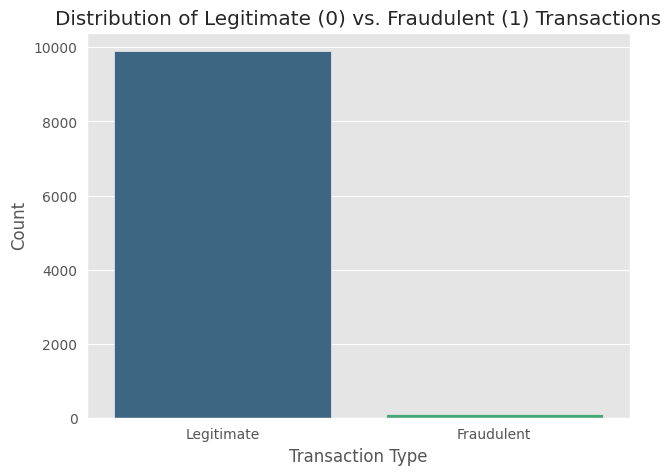

As expected, the dataset is highly imbalanced, which is common in fraud detection.


In [9]:
# Visualize the class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='is_fraud', data=df_fraud, palette='viridis')
plt.title('Distribution of Legitimate (0) vs. Fraudulent (1) Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
plt.show()

print("As expected, the dataset is highly imbalanced, which is common in fraud detection.")

In [10]:
# Prepare data for training
X = df_fraud.drop('is_fraud', axis=1)
y = df_fraud['is_fraud']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Fraudulent transactions in test set: {y_test.sum()} ({(y_test.sum()/len(y_test))*100:.2f}%)")

Training set size: 7000 samples
Test set size: 3000 samples
Fraudulent transactions in test set: 30 (1.00%)


In [11]:
# Initialize and train a RandomForestClassifier model
# RandomForests are excellent for classification tasks and handle imbalanced data reasonably well.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

print("RandomForestClassifier trained successfully!")

RandomForestClassifier trained successfully!


In [12]:
# Make predictions on the test set
y_pred = model_rf.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"### Model Evaluation for Fraud Detection ###\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n*   **Accuracy**: Overall correctness.")
print("*   **Precision**: Of all predicted frauds, how many were actually fraud (minimizes false positives).")
print("*   **Recall**: Of all actual frauds, how many were correctly identified (minimizes false negatives).")
print("*   **F1-Score**: Harmonic mean of Precision and Recall, balancing both.")


### Model Evaluation for Fraud Detection ###

Accuracy:  0.9910
Precision: 1.0000
Recall:    0.1000
F1-Score:  0.1818

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2970
           1       1.00      0.10      0.18        30

    accuracy                           0.99      3000
   macro avg       1.00      0.55      0.59      3000
weighted avg       0.99      0.99      0.99      3000


*   **Accuracy**: Overall correctness.
*   **Precision**: Of all predicted frauds, how many were actually fraud (minimizes false positives).
*   **Recall**: Of all actual frauds, how many were correctly identified (minimizes false negatives).
*   **F1-Score**: Harmonic mean of Precision and Recall, balancing both.


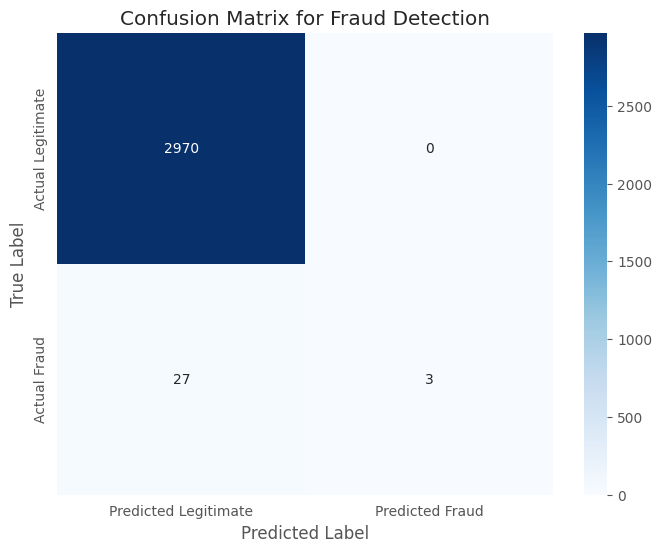

The confusion matrix helps us understand where our model made correct and incorrect predictions.

*   **True Positive (TP)**: Actual fraud correctly predicted as fraud.
*   **True Negative (TN)**: Actual legitimate transaction correctly predicted as legitimate.
*   **False Positive (FP)**: Actual legitimate transaction incorrectly predicted as fraud.
*   **False Negative (FN)**: Actual fraud incorrectly predicted as legitimate.


In [13]:
# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('Confusion Matrix for Fraud Detection')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("The confusion matrix helps us understand where our model made correct and incorrect predictions.")
print("\n*   **True Positive (TP)**: Actual fraud correctly predicted as fraud.")
print("*   **True Negative (TN)**: Actual legitimate transaction correctly predicted as legitimate.")
print("*   **False Positive (FP)**: Actual legitimate transaction incorrectly predicted as fraud.")
print("*   **False Negative (FN)**: Actual fraud incorrectly predicted as legitimate.")

---

# 📈 Application #2: Regression - Predicting Housing Prices: Your Dream Home's Value

Ever wondered how real estate websites estimate a home's value? This is where **Regression** comes into play! Unlike classification, which predicts categories, regression models predict **continuous numerical values**. In this section, we'll build a model to predict house prices based on various features, mimicking how services like Zillow or Redfin operate.

### 💻 Practical: Crafting a Price Predictor

In [14]:
# Import necessary libraries for Regression
from sklearn.datasets import fetch_california_housing # A classic dataset for regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler # For feature scaling

print("Regression-specific libraries loaded!")

Regression-specific libraries loaded!


In [15]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
df_housing['MedHouseVal'] = housing.target # Target variable: Median House Value

print("California Housing dataset loaded.")
print(f"Dataset shape: {df_housing.shape}")
print("\nFirst 5 rows of the dataset:")
display(df_housing.head())

print("\nDataset Information:")
df_housing.info()

California Housing dataset loaded.
Dataset shape: (20640, 9)

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
# Prepare data for training
X = df_housing.drop('MedHouseVal', axis=1)
y = df_housing['MedHouseVal']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features using StandardScaler
# This is important for many models, especially linear models and those sensitive to feature scales.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and features scaled successfully!")

Data split and features scaled successfully!


In [17]:
# Initialize and train a Linear Regression model
# Linear Regression is a fundamental model for predicting continuous values.
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [18]:
# Make predictions on the scaled test set
y_pred_lr = model_lr.predict(X_test_scaled)

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print(f"### Model Evaluation for Housing Price Prediction ###\n")
print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

print("\n*   **MAE**: Average absolute difference between actual and predicted values. Robust to outliers.")
print("*   **MSE**: Average of squared differences. Penalizes large errors more.")
print("*   **RMSE**: Square root of MSE. Interpretable in the same units as the target variable.")
print("*   **R-squared**: Proportion of variance in the dependent variable predictable from the independent variables. Higher is better.")

### Model Evaluation for Housing Price Prediction ###

Mean Absolute Error (MAE):  0.5272
Mean Squared Error (MSE):   0.5306
Root Mean Squared Error (RMSE): 0.7284
R-squared (R2): 0.5958

*   **MAE**: Average absolute difference between actual and predicted values. Robust to outliers.
*   **MSE**: Average of squared differences. Penalizes large errors more.
*   **RMSE**: Square root of MSE. Interpretable in the same units as the target variable.
*   **R-squared**: Proportion of variance in the dependent variable predictable from the independent variables. Higher is better.


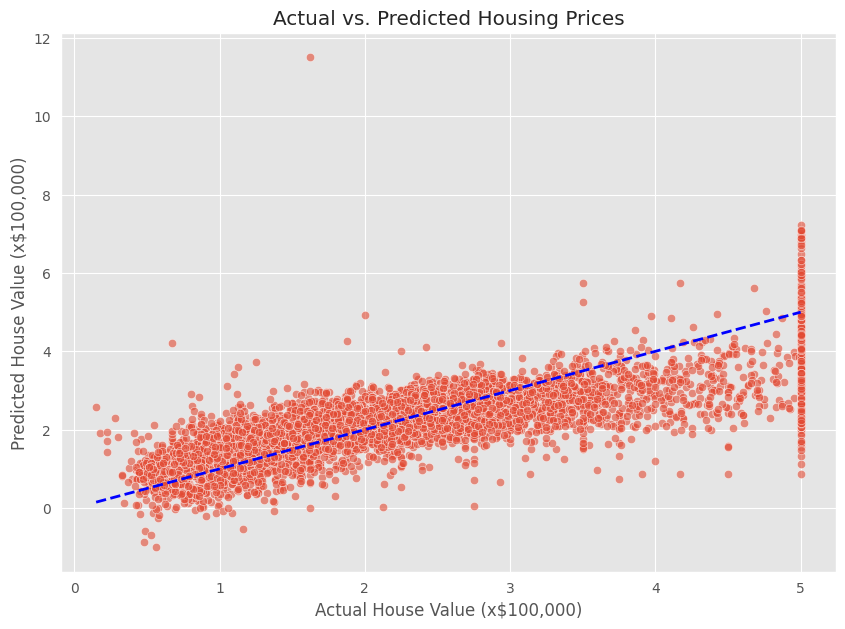

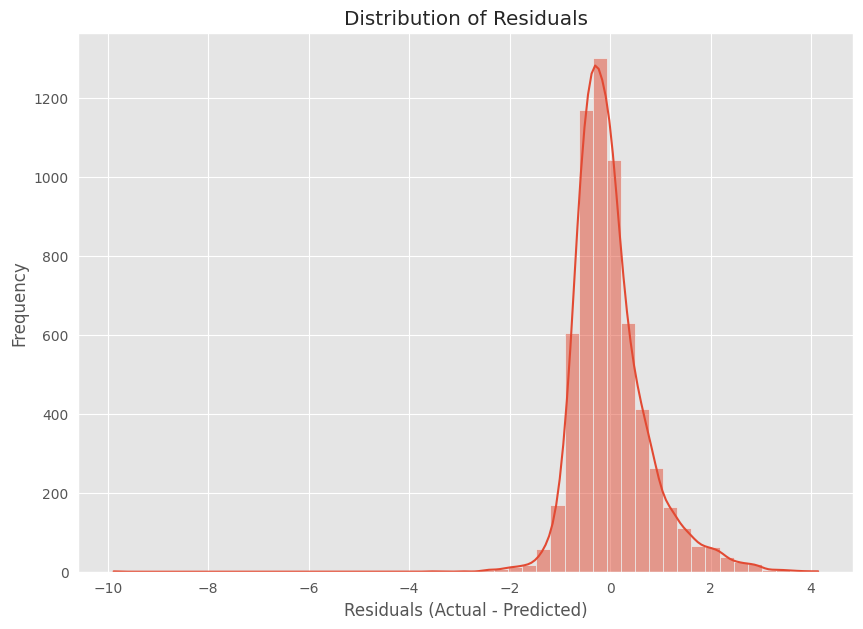

The scatter plot shows how close our predictions are to the actual values.
The residuals plot indicates the errors. Ideally, they should be normally distributed around zero.


In [20]:
# Visualize Actual vs. Predicted Prices
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2) # Ideal prediction line
plt.title('Actual vs. Predicted Housing Prices')
plt.xlabel('Actual House Value (x$100,000)')
plt.ylabel('Predicted House Value (x$100,000)')
plt.show()

# Visualize Residuals (Errors)
residuals = y_test - y_pred_lr
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

print("The scatter plot shows how close our predictions are to the actual values.")
print("The residuals plot indicates the errors. Ideally, they should be normally distributed around zero.")

---

# 🔍 Application #3: Clustering - Unveiling Customer Segments: Who Are Your Customers?

Imagine you're a marketing manager trying to tailor campaigns. Sending the same message to everyone rarely works. This is where **Clustering** shines! Clustering is an **unsupervised learning** technique that groups similar data points together without any prior knowledge of their labels. For customer segmentation, it helps businesses understand different customer groups based on their purchasing behavior, demographics, or activity patterns.

We'll use the KMeans algorithm to discover natural groupings within a synthetic customer dataset.

### 💻 Practical: Discovering Customer Segments

In [21]:
# Import necessary libraries for Clustering
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs # For generating synthetic clustering data

print("Clustering-specific libraries loaded!")

Clustering-specific libraries loaded!


In [ ]:
# Generate a synthetic dataset for customer segmentation
# We'll create data with distinct clusters to simulate different customer groups
X, y_true = make_blobs(
    n_samples=500,        # Number of customers
    centers=4,            # Number of distinct customer segments
    cluster_std=0.8,      # Standard deviation of clusters
    random_state=42       # For reproducibility
)

# For visualization and analysis, let's assume two main features (e.g., Annual Income, Spending Score)
df_customers = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])

print("Synthetic customer segmentation dataset created.")
print(f"Dataset shape: {df_customers.shape}")
print("\nFirst 5 rows of the dataset:")
display(df_customers.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df_customers, palette='deep', s=100, alpha=0.7)
plt.title('Raw Customer Data (Pre-Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

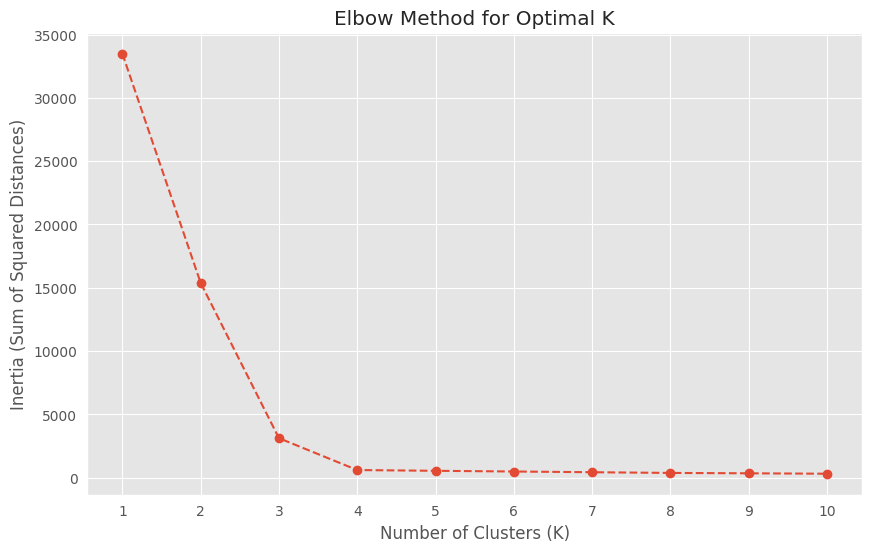

The 'elbow' in the plot suggests the optimal number of clusters.


In [23]:
# Determining the optimal number of clusters (k) using the Elbow Method
# The Elbow Method plots the sum of squared distances from each point to its assigned center (inertia)
# We look for the 'elbow' point where the decrease in inertia slows down significantly.

inertia = []
K_range = range(1, 11) # Test k from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for robust initialization
    kmeans.fit(df_customers)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(K_range)
plt.show()

print("The 'elbow' in the plot suggests the optimal number of clusters.")

In [24]:
# Based on the Elbow Method, let's assume the optimal k is 4.
# Initialize and train KMeans with the chosen number of clusters
k_optimal = 4 # Or chosen from the Elbow plot
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_model.fit(df_customers)

# Add the cluster labels to our DataFrame
df_customers['Cluster'] = kmeans_model.labels_

print(f"KMeans clustering with {k_optimal} clusters applied successfully!")
print("\nFirst 5 rows with cluster assignments:")
display(df_customers.head())

KMeans clustering with 4 clusters applied successfully!

First 5 rows with cluster assignments:


,Annual Income (k$),Spending Score (1-100),Cluster
0,-7.918909,6.760982,1
1,-9.037137,-6.923545,2
2,6.391721,1.326531,0
3,-2.822884,7.843474,3
4,-5.918656,-7.206570,2


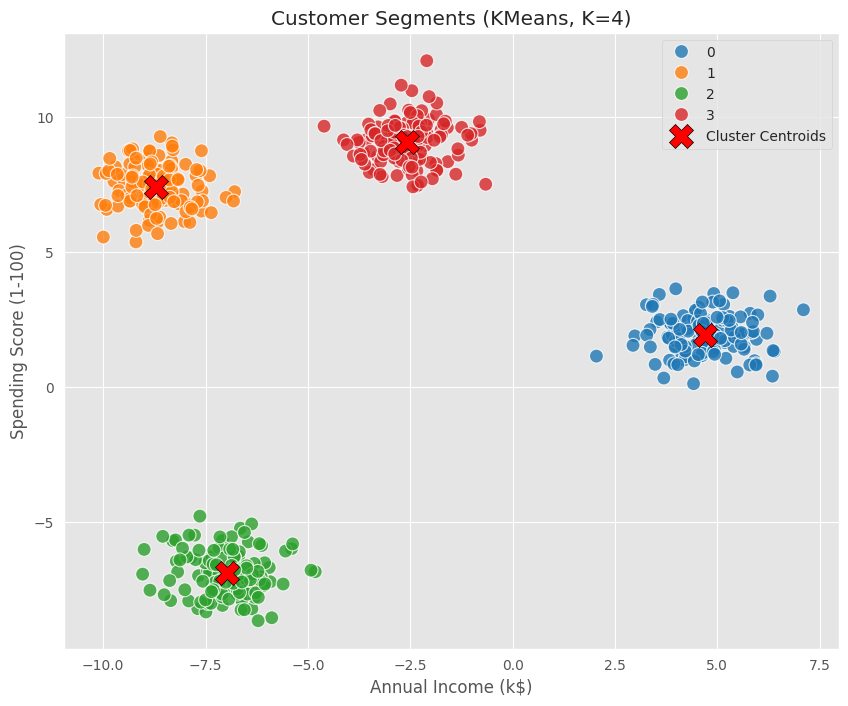

Each color represents a distinct customer segment, centered around the red 'X' marks.
Businesses can now tailor marketing strategies to these specific groups.


In [25]:
# Visualize the Customer Segments
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster',
                data=df_customers, palette='tab10', s=100, alpha=0.8)

# Plot cluster centers
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Cluster Centroids', edgecolor='black')

plt.title(f'Customer Segments (KMeans, K={k_optimal})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print("Each color represents a distinct customer segment, centered around the red 'X' marks.")
print("Businesses can now tailor marketing strategies to these specific groups.")

---

# 🧠 How to Choose the Right Model: A Decision-Maker's Guide

With so many ML models available, how do you pick the right one for your problem? The key lies in understanding your **problem type** and the **nature of your data**. Here's a simplified guide based on our applications:

| Problem Type       | Example                 | What it does                                          | Model Used           |
| :----------------- | :---------------------- | :---------------------------------------------------- | :------------------- |
| **Classification** | Fraud Detection         | Categorizes data into discrete classes (e.g., A/B)   | RandomForestClassifier |
| **Regression**     | Housing Price Prediction | Predicts continuous numerical values (e.g., 100.5, 2500) | LinearRegression     |
| **Clustering**     | Customer Segmentation   | Groups similar data points without prior labels       | KMeans               |

### General Guidelines:

*   **Supervised Learning** (Classification, Regression): You have labeled data (input features + target output).
    *   **Classification** for discrete outcomes.
    *   **Regression** for continuous outcomes.
*   **Unsupervised Learning** (Clustering): You have unlabeled data and want to find hidden patterns or structures.

This table provides a starting point, but the choice often involves experimentation, considering data size, dimensionality, linearity, and interpretability requirements.

---

# ⚙️ Mini End-to-End Project: Enhancing Housing Price Prediction with Feature Engineering

Now, let's bring it all together! We'll revisit our housing price prediction task, but this time, we'll go through a more complete ML pipeline: from data cleaning and **feature engineering** to advanced model training and evaluation. This section will highlight how transforming raw data into meaningful features can significantly boost model performance.

### 💻 The Full ML Workflow

In [26]:
# Reload the California Housing dataset for a fresh start in this section
housing_e2e = fetch_california_housing(as_frame=True)
df_e2e = housing_e2e.frame
df_e2e['MedHouseVal'] = housing_e2e.target

print("California Housing dataset reloaded for E2E project.")
print(f"Dataset shape: {df_e2e.shape}")
display(df_e2e.head())

California Housing dataset reloaded for E2E project.
Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [27]:
### Data Cleaning & Preprocessing

# Check for missing values
print("\nMissing values before cleaning:")
print(df_e2e.isnull().sum())

# The California housing dataset is remarkably clean, but in a real scenario,
# we would handle missing values (e.g., imputation, dropping rows/columns).

# Feature Scaling (as before, crucial for many models)
scaler_e2e = StandardScaler()
X_e2e = df_e2e.drop('MedHouseVal', axis=1)
y_e2e = df_e2e['MedHouseVal']

X_e2e_scaled = scaler_e2e.fit_transform(X_e2e)
X_e2e_scaled_df = pd.DataFrame(X_e2e_scaled, columns=X_e2e.columns)

print("\nData cleaning (missing value check) and scaling complete.")
display(X_e2e_scaled_df.head())


Missing values before cleaning:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Data cleaning (missing value check) and scaling complete.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [28]:
### Feature Engineering

# Let's create some new features that might capture more complex relationships.
# For example, interactions between existing features or polynomial features.

# We'll add a 'HouseAge_x_AveRooms' interaction term
X_e2e_scaled_df['HouseAge_x_AveRooms'] = X_e2e_scaled_df['HouseAge'] * X_e2e_scaled_df['AveRooms']

# Let's also add polynomial features for 'MedInc' (Median Income) to capture non-linearities
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False) # degree 2 means up to x^2

# We need to extract 'MedInc' as a 2D array for PolynomialFeatures
medinc_poly = poly.fit_transform(X_e2e_scaled_df[['MedInc']])
medinc_poly_df = pd.DataFrame(medinc_poly, columns=[f'MedInc_poly_{i}' for i in range(medinc_poly.shape[1])])

# Drop original 'MedInc' and concatenate polynomial features
X_e2e_final = pd.concat([X_e2e_scaled_df.drop('MedInc', axis=1), medinc_poly_df], axis=1)

print("Feature engineering complete. New features added!")
print(f"New dataset shape: {X_e2e_final.shape}")
display(X_e2e_final.head())

Feature engineering complete. New features added!
New dataset shape: (20640, 10)


,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseAge_x_AveRooms,MedInc_poly_0,MedInc_poly_1
0,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,0.617335,2.344766,5.497926
1,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,-0.198520,2.332238,5.439334
2,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,2.145041,1.782699,3.178017
3,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,0.291358,0.932968,0.870428
4,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,0.639846,-0.012881,0.000166


In [29]:
### Model Training with an Advanced Regressor

# Split the dataset with engineered features into training and testing sets
X_train_e2e, X_test_e2e, y_train_e2e, y_test_e2e = train_test_split(X_e2e_final, y_e2e, test_size=0.3, random_state=42)

# For this E2E project, let's use a more powerful model: GradientBoostingRegressor
# Gradient Boosting models often provide higher accuracy than simple Linear Regression.
from sklearn.ensemble import GradientBoostingRegressor

model_gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
model_gbr.fit(X_train_e2e, y_train_e2e)

print("GradientBoostingRegressor trained successfully with engineered features!")

GradientBoostingRegressor trained successfully with engineered features!


In [30]:
### Model Evaluation & Visualization

# Make predictions on the test set with the Gradient Boosting model
y_pred_gbr = model_gbr.predict(X_test_e2e)

# Evaluate the model's performance
mae_gbr = mean_absolute_error(y_test_e2e, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_e2e, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test_e2e, y_pred_gbr)

print(f"### Model Evaluation for Enhanced Housing Price Prediction (Gradient Boosting) ###\n")
print(f"Mean Absolute Error (MAE):  {mae_gbr:.4f}")
print(f"Mean Squared Error (MSE):   {mse_gbr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.4f}")
print(f"R-squared (R2): {r2_gbr:.4f}")

# Compare with previous Linear Regression model (from Application #2)
print("\n--- Comparison with Simple Linear Regression ---")
print(f"Linear Regression R-squared: {r2:.4f}")
print(f"Gradient Boosting R-squared: {r2_gbr:.4f}")
print("\n*Observation: Feature engineering and a more advanced model have likely improved R-squared!*\n")

### Model Evaluation for Enhanced Housing Price Prediction (Gradient Boosting) ###

Mean Absolute Error (MAE):  0.3192
Mean Squared Error (MSE):   0.2240
Root Mean Squared Error (RMSE): 0.4732
R-squared (R2): 0.8294

--- Comparison with Simple Linear Regression ---
Linear Regression R-squared: 0.5958
Gradient Boosting R-squared: 0.8294

*Observation: Feature engineering and a more advanced model have likely improved R-squared!*



In [31]:
# Advanced Visualization: Actual vs. Predicted with Plotly for interactivity
import plotly.express as px

# Create a DataFrame for plotting
plot_df = pd.DataFrame({'Actual': y_test_e2e, 'Predicted': y_pred_gbr, 'Residuals': y_test_e2e - y_pred_gbr})

fig = px.scatter(
    plot_df, x='Actual', y='Predicted',
    title='Actual vs. Predicted Housing Prices (Gradient Boosting)',
    labels={'Actual': 'Actual House Value ($100k)', 'Predicted': 'Predicted House Value ($100k)'},
    hover_data=['Residuals']
)
fig.add_shape(
    type='line', line=dict(dash='dash', color='red'),
    x0=plot_df['Actual'].min(), y0=plot_df['Actual'].min(),
    x1=plot_df['Actual'].max(), y1=plot_df['Actual'].max()
)
fig.show()

print("This interactive scatter plot allows you to hover over points and see actual, predicted, and residual values.")

This interactive scatter plot allows you to hover over points and see actual, predicted, and residual values.


---

# 📊 Advanced Visualization: Bringing Data to Life

Visualizations are the storytelling backbone of any data science project. They transform complex numbers into intuitive insights, crucial for both understanding and communicating your model's performance. Throughout this notebook, we've used `matplotlib` and `seaborn` for static plots. Here, we've introduced `plotly` for interactive charts, which is fantastic for a deeper, exploratory analysis.

Key visual takeaways from our journey:

*   **Class Distribution** (Fraud Detection): Instantly revealed the severe imbalance, a critical challenge in fraud modeling.
*   **Confusion Matrix Heatmap** (Fraud Detection): Provided a clear picture of true positives, true negatives, false positives, and false negatives, vital for assessing model risk.
*   **Actual vs. Predicted Scatter Plots** (Housing Prices): Showed how well our regression models aligned with reality, with an ideal diagonal line indicating perfect prediction.
*   **Residuals Distribution** (Housing Prices): Helped diagnose if our model's errors were random or systematic.
*   **Elbow Method Plot** (Customer Segmentation): Guided us to choose the optimal number of clusters for meaningful segmentation.
*   **Cluster Visualizations** (Customer Segmentation): Visually confirmed the distinct customer groups, making it easy to see patterns.

---

## 🌍 Real-World Impact: More Than Just Numbers

It's easy to get lost in algorithms and metrics, but at its heart, Machine Learning is about making an impact. The models we've explored today have profound real-world consequences:

*   **Lives (Healthcare)**: An ML model detecting early signs of a disease can literally save a life. Conversely, a biased model might misdiagnose certain demographics, leading to tragic outcomes.
*   **Money (Finance & E-commerce)**: Our fraud detection model protects individuals and institutions from financial loss. A robust price prediction model can help families make informed decisions about their biggest investment. Effective customer segmentation directly translates to more efficient marketing and higher revenue.
*   **Experience (Recommendation Systems & Social Media)**: While we didn't build one today, the same principles apply. A good recommendation system enhances your online experience, while a flawed one can lead to frustration or reinforce filter bubbles.

Every decision, every prediction from these models, whether correct or incorrect, ripples through society, affecting individuals, businesses, and even public policy. Understanding this impact is crucial for any aspiring ML practitioner.

---

# ⚠️ Limitations of ML Applications: The Road Ahead is Not Without Bumps

While incredibly powerful, Machine Learning is not a silver bullet. It's vital to acknowledge its limitations and potential pitfalls:

*   **Bias**: ML models learn from data. If the data reflects societal biases (e.g., historical discrimination), the model will perpetuate and even amplify those biases. This can lead to unfair or discriminatory outcomes in critical areas like hiring, lending, or criminal justice.
*   **Data Dependency**: Models are only as good as the data they're trained on. Poor quality data, insufficient data, or data that doesn't represent the real world accurately will lead to poor model performance.
*   **Ethical Concerns**: The use of ML raises significant ethical questions regarding privacy, surveillance, autonomy, and accountability. Who is responsible when an autonomous vehicle causes an accident, or when an AI system makes a flawed medical diagnosis?
*   **Lack of Interpretability ('Black Box')**: Complex models like deep neural networks or large ensemble methods can be difficult to interpret, making it hard to understand *why* they make certain predictions. This can be problematic in high-stakes applications where explainability is crucial.
*   **Overfitting**: Models can become too specialized to the training data, performing poorly on new, unseen data. This is a constant challenge in model development.

Addressing these limitations requires not just technical expertise, but also a deep understanding of ethics, domain knowledge, and a commitment to fairness and transparency.

---

# 🧠 Key Takeaways: Your ML Wisdom in a Nutshell

Let's distill the essence of our journey into actionable insights:

1.  **Problem Dictates Model**: Always start by clearly defining your problem (classification, regression, clustering) before choosing an algorithm.
2.  **Data is Gold**: The quality, quantity, and preparation of your data are paramount to model success.
3.  **Metrics Matter**: Don't just rely on accuracy; understand precision, recall, F1-score, RMSE, etc., based on your problem's specific needs.
4.  **Visualize for Insight**: Plots and charts are essential for understanding data, diagnosing model performance, and communicating results.
5.  **ML is Interdisciplinary**: It blends computer science, statistics, domain expertise, and ethics.
6.  **Impact and Responsibility**: Recognize the real-world implications of your models and strive for fairness and transparency.



---

# 📌 Conclusion: The Future is Machine Learning Powered

And so our immersive journey through the applications of Machine Learning comes to an end. You've witnessed ML transform raw data into actionable insights, whether it's flagging fraud, valuing homes, or segmenting customers. You've seen that Machine Learning is not just about complex algorithms or lines of code; **it's about impact**.

It's about empowering businesses, enhancing daily life, and even pushing the boundaries of scientific discovery. As you continue your ML adventure, remember the stories, the challenges, and the immense potential you've uncovered today.

The real world is your lab, and Machine Learning is your most powerful tool. Keep exploring, keep learning, and keep building!

**Thank you for joining this lecture!** 🙏